# Baseline Model — Regresión Lineal

## Objetivo de este notebook

Establecer un modelo de referencia usando **Regresión Lineal** antes de explorar
algoritmos más complejos. El baseline sirve para:
1. Verificar que el pipeline de datos es correcto (predicciones razonables = datos bien procesados)
2. Fijar un umbral de comparación para modelos avanzados (Notebook 05)
3. Analizar los residuos para detectar problemas sistemáticos en las predicciones

**Configuración:**
- Split train/test: 80% / 20% con `random_state=42`
- Métrica principal: **RMSE en escala logarítmica** (métrica oficial Kaggle)
- Validación: K-Fold Cross Validation con cv=10

**Input:** `data/train_features.csv` (46 features + target `SalePrice_log`)

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path

# Modelo y evaluación
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Crea la carpeta images/ en la raíz del proyecto si no existe
Path('../../images').mkdir(exist_ok=True)

Lectura del Data Frame Final para el Modelo, libre de nulos y con las variables finales seleccionadas.

In [2]:
data_path = Path('../../data/train_features.csv')
# keep_default_na=False desactiva la interpretación automática de nulos
# na_values=[] lista vacía — ningún valor adicional se interpreta como nulo
df = pd.read_csv(data_path, keep_default_na=False, na_values=[''])

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
df.columns

Filas: 1460
Columnas: 47
Nulos totales: 0


Index(['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath',
       'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF',
       '2ndFlrSF', 'OpenPorchSF', 'HalfBath', 'property_age',
       'year_since_remod', 'ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC',
       'BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'PavedDrive',
       'LotShape', 'Foundation_CBlock', 'Foundation_PConc', 'Foundation_Slab',
       'Foundation_Stone', 'Foundation_Wood', 'GarageType_Attchd',
       'GarageType_Basment', 'GarageType_BuiltIn', 'GarageType_CarPort',
       'GarageType_Detchd', 'GarageType_None', 'MSZoning_FV', 'MSZoning_RH',
       'MSZoning_RL', 'MSZoning_RM', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial', 'CentralAir', 'Neighborhood', 'SalePrice_log'],
      dtype='str')

## 1. Modelo Baseline con Regresión Lineal

### Configuración del Dataset
- **Features (X):** 46 variables (numéricas, ordinales, one-hot y binarias)
- **Target (y):** SalePrice_log, precio transformado con np.log()
- **Train set:** 1,168 observaciones (80%)
- **Test set:** 292 observaciones (20%)
- **random_state=42** garantiza reproducibilidad del split

In [3]:
X = df.drop('SalePrice_log', axis = 1)
y = df['SalePrice_log']

print(f'Shape X: {X.shape}')
print(f'Shape Y: {y.shape}')

x_train, x_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

print(f"Training Data Set: {x_train.shape[0]} filas")
print(f"Test Data Set: {x_test.shape[0]} filas")


model_log = LinearRegression()
model_log.fit(x_train, y_train)

y_pred_log = model_log.predict(x_test)

# Metricas Sale Price Log
mae_log = mean_absolute_error(y_test,y_pred_log)
mse_log = mean_squared_error(y_test,y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test,y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

print(f"MAE (log): {mae_log}")
print(f"MSE (log): {mse_log}")
print(f"RMSE (log): {rmse_log}")
print(f"R² (log): {r2_log}")

# Reconvesion a escala original
y_pred_usd = np.exp(y_pred_log)
y_test_usd = np.exp(y_test)

# Metricas Sale Price USD
mae_usd = mean_absolute_error(y_test_usd,y_pred_usd)
mse_usd = mean_squared_error(y_test_usd,y_pred_usd)
rmse_usd = np.sqrt(mean_squared_error(y_test_usd,y_pred_usd))
r2_usd = r2_score(y_test_usd, y_pred_usd)

print(f"MAE (USD): {mae_usd}")
print(f"MSE (USD): {mse_usd}")
print(f"RMSE (USD): {rmse_usd}")
print(f"R² (USD): {r2_usd}")



Shape X: (1460, 46)
Shape Y: (1460,)
Training Data Set: 1168 filas
Test Data Set: 292 filas
MAE (log): 0.09685565022697402
MSE (log): 0.01733983057000682
RMSE (log): 0.13168079043659642
R² (log): 0.9070815944481962
MAE (USD): 17076.04256388444
MSE (USD): 694931505.6921498
RMSE (USD): 26361.553552325968
R² (USD): 0.9094000063464058



### Métricas en Escala Logarítmica (perspectiva técnica)
| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| MAE (log) | 0.0969 | Error promedio absoluto en log-escala |
| RMSE (log) | 0.1317 | Error penalizando outliers en log-escala |
| R² (log) | 0.9071 | El modelo explica el 90.7% de la varianza |

### Métricas en USD (perspectiva de negocio)
| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| MAE (USD) | $17,076 | En promedio el modelo se equivoca $17,076 por casa |
| RMSE (USD) | $26,361 | Benchmark Kaggle $25,000, $1,361 por encima|
| R² (USD) | 0.9094 | El modelo explica el 90.9% de la varianza del precio |

### Resumen General
El baseline con regresión lineal es sólido para un primer modelo. Un R² superior 
a 0.90 indica buen poder explicativo. Sin embargo, el RMSE supera levemente el 
benchmark de Kaggle ($25,000), lo que justifica explorar modelos más complejos 
en la Fase 5 (XGBoost).

La diferencia entre MAE ($17,076) y RMSE ($26,361) sugiere errores grandes en 
casas de alto valor, producto de relaciones no lineales que la regresión lineal 
no puede capturar.

## Gráfico 1 - Real vs Predicho (Escala Log y USD)

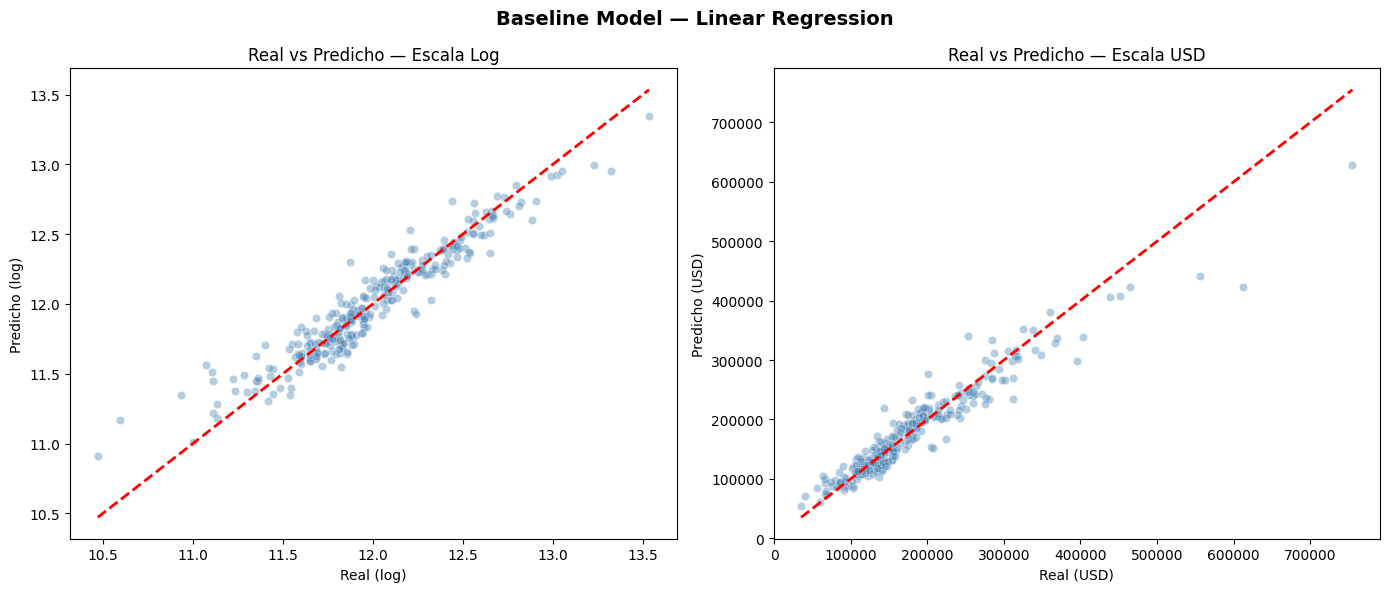

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: escala logarítmica (métrica oficial Kaggle) ---
# Si los puntos siguen la diagonal roja → predicciones perfectas
axes[0].scatter(
    y_test, y_pred_log,
    alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5
)
min_val = min(y_test.min(), y_pred_log.min())
max_val = max(y_test.max(), y_pred_log.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_xlabel('Real (log)')
axes[0].set_ylabel('Predicho (log)')
axes[0].set_title('Real vs Predicho — Escala Log')

# --- Subplot 2: escala USD (perspectiva de negocio) ---
# La dispersión visual es mayor en USD porque la escala no está comprimida
axes[1].scatter(
    y_test_usd, y_pred_usd,
    alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5
)
min_val = min(y_test_usd.min(), y_pred_usd.min())
max_val = max(y_test_usd.max(), y_pred_usd.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Real (USD)')
axes[1].set_ylabel('Predicho (USD)')
axes[1].set_title('Real vs Predicho — Escala USD')

plt.suptitle('Baseline Model — Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../images/04_real_vs_predicho.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Observaciones generales:**
- La gran mayoria de puntos se encuentran alrededor de la diagonal,
  indicando que el modelo tiene un comportamiento general aceptable.

**Casas de menor precio:**
- Varios outliers por encima de la diagonal indican que el modelo
  sobreestima propiedades de bajo valor (predicho > real).

**Casas de mayor precio:**
- Los puntos mas alejados de la diagonal se concentran en el segmento
  de alto valor ($300K+), ubicados por debajo de la diagonal, indicando
  subestimacion sistematica (predicho < real).

**Escala USD vs Escala Log:**
- La dispersion visual es mayor en USD debido a que la escala logaritmica
  comprime las distancias entre valores grandes, facilitando la lectura
  tecnica del comportamiento del modelo.

## Grafico 2 - Residuos vs Predicciones (Escala Log)

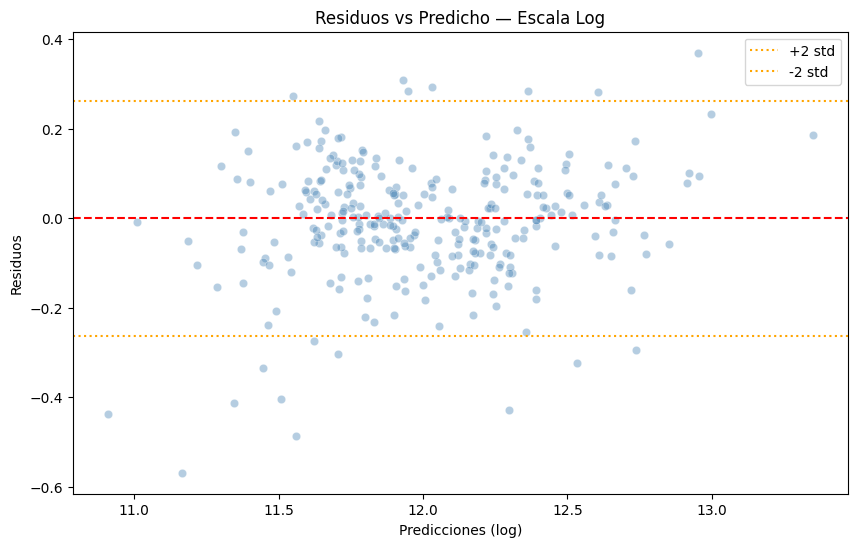

In [5]:
# Residuo = y_real - y_predicho
# Positivo → el modelo subestimó | Negativo → el modelo sobreestimó
res = y_test - y_pred_log

plt.figure(figsize=(10, 6))
plt.scatter(
    y_pred_log, res,
    alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5
)
plt.axhline(y=0, color='r', linestyle='--')  # Línea de referencia: error cero
plt.xlabel('Predicciones (log)')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicho — Escala Log')

# Bandas de ±2 desviaciones estándar: ~95% de los residuos deberían estar dentro
std_res = np.std(res)
plt.axhline(y= 2 * std_res, color='orange', linestyle=':', linewidth=1.5, label='+2 std')
plt.axhline(y=-2 * std_res, color='orange', linestyle=':', linewidth=1.5, label='-2 std')
plt.legend()
plt.savefig('../../images/04_residuos_predicciones.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Interpretacion del grafico:**
- Eje X: valor predicho por el modelo en escala logaritmica
- Eje Y: residuo = y_real - y_predicho
  - Residuo positivo -> modelo subestimo (predicho < real)
  - Residuo negativo -> modelo sobreestimo (predicho > real)

**Rango central (11.5 a 12.5):**
- Los residuos se distribuyen aleatoriamente alrededor de cero,
  indicando comportamiento estable del modelo en el rango medio de precios.

**Extremos:**
- Predicciones bajas (X < 11.5): predominan residuos negativos,
  el modelo tiende a sobreestimar propiedades de bajo valor.
- Predicciones altas (X > 12.5): predominan residuos positivos,
  el modelo tiende a subestimar propiedades de alto valor.
  Confirma el patron observado en el grafico Real vs Predicho.

**Outliers de error:**
- Aproximadamente 20 puntos caen fuera de las lineas naranjas (+-2 std),
  representando el 6.8% de las observaciones ligeramente por encima
  del 5% esperado bajo distribucion normal.
- Estos casos corresponden a propiedades donde el modelo
  fallo significativamente en la prediccion.

## Grafico 3 - Distribucion de Residuos (Histograma)

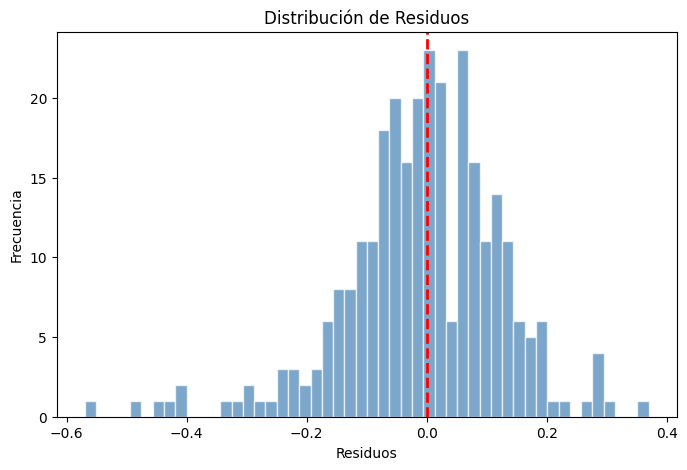

In [6]:
# Histograma de residuos — verifica el supuesto de normalidad de la regresión lineal
# Una distribución aproximadamente gaussiana centrada en cero indica buen ajuste
plt.figure(figsize=(8, 5))
plt.hist(res, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)  # Residuo cero ideal
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.savefig('../../images/04_distribucion_residuos.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Interpretacion del grafico:**
- Eje X: valor del residuo (y_real - y_predicho)
- Eje Y: frecuencia de observaciones por rango de residuo
  - Residuos negativos (izquierda) -> sobreestimacion
  - Residuos positivos (derecha)   -> subestimacion

**Forma de la distribucion:**
- Aproximadamente gaussiana y centrada cerca de cero,
  lo que indica que el modelo no tiene un sesgo sistematico grave.
- El pico principal se ubica ligeramente a la derecha de cero,
  sugiriendo una leve tendencia a subestimar en el rango mas frecuente.

**Colas:**
- Cola izquierda (residuos negativos hasta -0.6): mas larga y pronunciada,
  confirma que los casos de sobreestimacion extrema son mas frecuentes
  que los de subestimacion extrema.
- Cola derecha (residuos positivos hasta +0.4): mas corta,
  corresponde principalmente a casas de alto valor subestimadas.

**Conclusion:**
- La distribucion aproximadamente normal de los residuos confirma que
  el supuesto de normalidad de la regresion lineal se cumple razonablemente.
- Las colas indican casos donde el modelo falla en los extremos del
  rango de precios, consistente con los graficos anteriores.

### K-Fold Cross Validation (cv=10)

**Objetivo:**
Verificar que el RMSE obtenido en el split 80/20 no fue producto
del azar de la semilla (random_state=42), sino que el modelo
es estable y generalizable ante diferentes particiones de los datos.

In [7]:
cv_scores = cross_val_score(
    model_log,
    X,
    y,
    cv=10,
    scoring="neg_mean_squared_error"
)

cv_rmse = np.sqrt(-cv_scores)

print(f'RMSE por fold:{cv_rmse}')
print(f'RMSE promedio (log): {np.mean(cv_rmse):.4f}')
print(f'Desviación estándar (log): {np.std(cv_rmse):.4f}')

RMSE por fold:[0.12115041 0.11428808 0.13779447 0.1776418  0.15577281 0.1140325
 0.12966806 0.12422537 0.24197828 0.14654677]
RMSE promedio (log): 0.1463
Desviación estándar (log): 0.0371


**Resultados por fold:**
| Fold | RMSE (log) |
|------|------------|
| 1  | 0.1212 |
| 2  | 0.1143 |
| 3  | 0.1378 |
| 4  | 0.1776 |
| 5  | 0.1558 |
| 6  | 0.1140 |
| 7  | 0.1297 |
| 8  | 0.1242 |
| 9  | 0.2420 |
| 10 | 0.1465 |

**Metricas de estabilidad:**
- RMSE promedio (log): 0.1463 - consistente con el RMSE del split (0.1317)
- Desviacion estandar (log): 0.0371 - varianza aceptable entre folds

**Observaciones:**
- 9 de 10 folds presentan RMSE entre 0.11 y 0.18, confirmando estabilidad.
- El fold 9 (RMSE=0.2420) es un outlier probablemente concentro
  propiedades de alto valor donde el modelo pierde precision.
- La cercania entre el RMSE promedio del K-Fold (0.1463) y el RMSE
  del split simple (0.1317) confirma que el resultado no fue producto
  del azar sino del comportamiento real del modelo.

---

## Conclusiones — Baseline Model

### Rendimiento del modelo

| Métrica | Valor | Referencia |
|---------|-------|------------|
| **RMSE (log)** | **0.1317** | Benchmark Kaggle: 0.1358 ✅ |
| RMSE (USD) | $26,361 | — |
| R² | 0.909 | El modelo explica el 90.9% de la varianza |
| MAE (USD) | $17,076 | Error promedio por propiedad |

### Evaluación de supuestos de la regresión lineal
- **Normalidad de residuos:** Distribución aproximadamente gaussiana centrada en cero ✅
- **Homocedasticidad:** Residuos sin patrón de embudo en el rango central ✅
- **Outliers:** ~6.8% de observaciones fuera de ±2 std (esperado ≤ 5%) — aceptable

### Hallazgos clave
- El baseline **supera el benchmark de Kaggle** (RMSE log 0.1317 vs 0.1358) con un modelo simple
- La diferencia MAE ($17k) vs RMSE ($26k) señala errores grandes en propiedades de alto valor — relaciones no lineales que la regresión lineal no captura
- K-Fold con cv=10 confirma estabilidad: RMSE promedio 0.1463 con std 0.0371; el fold 9 (RMSE=0.2420) concentró propiedades de alto valor
- El resultado no fue producto del azar de `random_state=42` — está validado por cross-validation

### Próximo paso
**Notebook 05** — XGBoost y Ridge Regression para intentar capturar las relaciones no lineales en el segmento premium.